### [K線捕手](https://www.facebook.com/kevinyang20180801)  
  
[專買黑馬股3：K線捕手楊忠憲教你，用1張表逮飆股](https://www.books.com.tw/products/0011010836)  
  
[1月22日新書](https://www.facebook.com/kevinyang20180801/posts/pfbid0pmptiBd3U3YxWTVVjM1id4J7E8AdP9BJYmo24CWCaU1up9Ps4jHJVfE9XntKcEFal)即將上市。  
感謝平民股神蘇松泙老師推薦~  
  
🔥新春加碼只有這次🔥今年你不能錯過的好康！  
1/12（日） 楊忠憲【高人氣講座】即將開講！感謝大家的踴躍支持～  
實體場次：https://smartpub.pse.is/6sveb5  
直播場次：https://smartpub.pse.is/6svee8  
本場活動特別加碼⚡️僅實體場次！  
✦報到即贈智富月刊1本  
✦現場1.5小時互動教學：  
手把手教你𝐊線捕手投資心法：個案研討、投資策略…任何你想了解的投資秘密㊙️  
\*加碼活動因學員隱私問題，將不會直播、錄影  
只要你想在股市中獲利出場，就絕對不能錯過這次機會！  
實體場次：如臨時無法抵達現場，請盡速與客服聯繫更換成直播場次(@smart888)，也讓小編可以即時釋出實體場次座位  
各位同學今天下午見~  
  
✨下課囉✨  
今日分享會內容超級扎實~希望同學都收穫滿滿！  
祝各位投資順利💕  
  
舊生專屬優惠⭐優惠價\\$13,500元(原價\\$24,000元)  
實體班：https://smartpub.pse.is/6ry97t  
直播班：https://smartpub.pse.is/6ry997  
【實體、直播同步開課，雙向學習無憂無慮】  
  
【Smart自學網 客服】  
🌐LINE@好友：https://reurl.cc/0vvQZb  

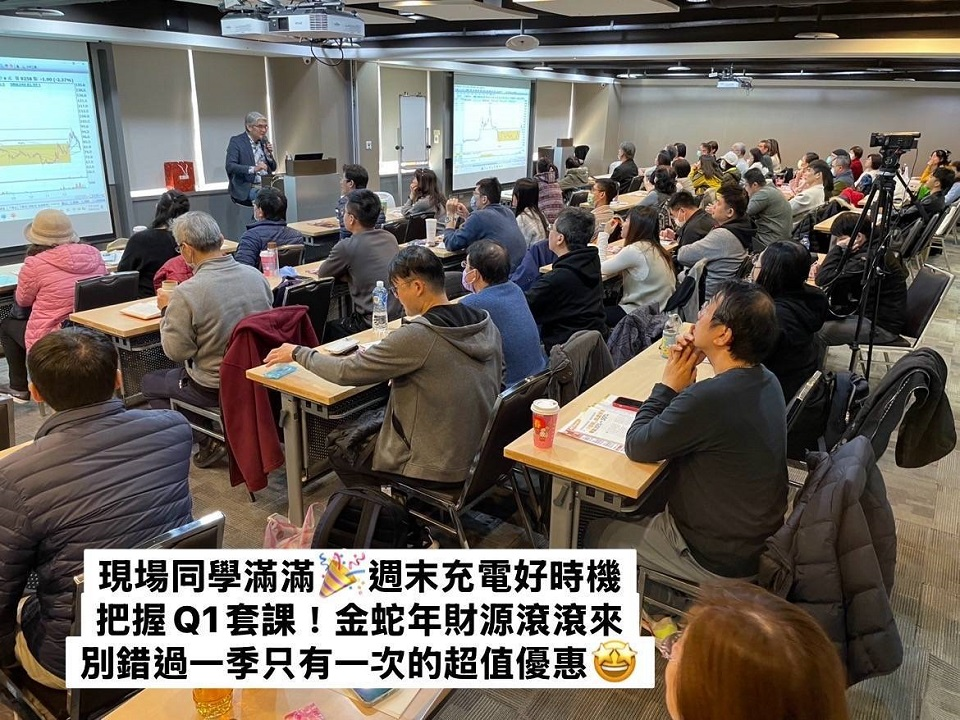  
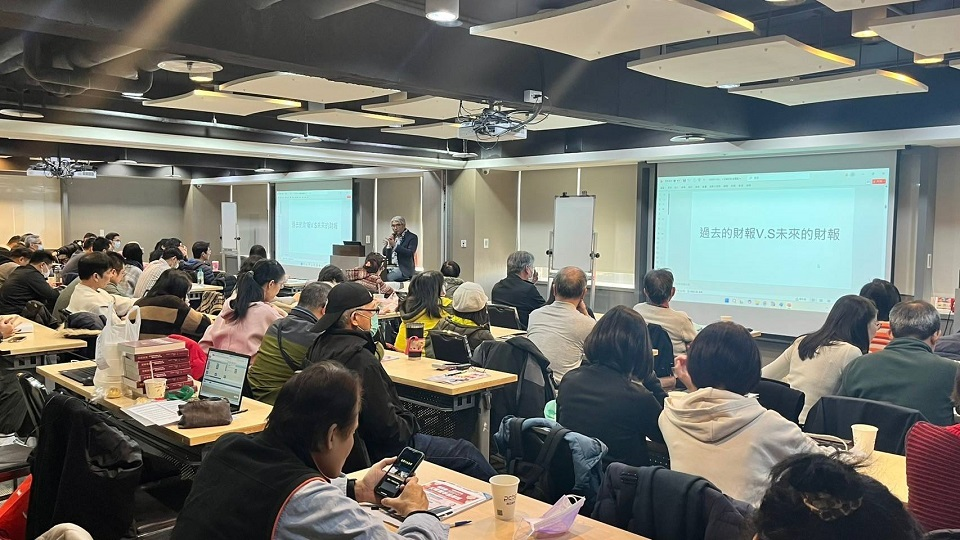  

### 【[周末影音解盤](https://www.facebook.com/kevinyang20180801/videos/2028093687612772?st=54G5XFdoRk9)】20250112  
https://fb.watch/x3jAV9RP_Q/  

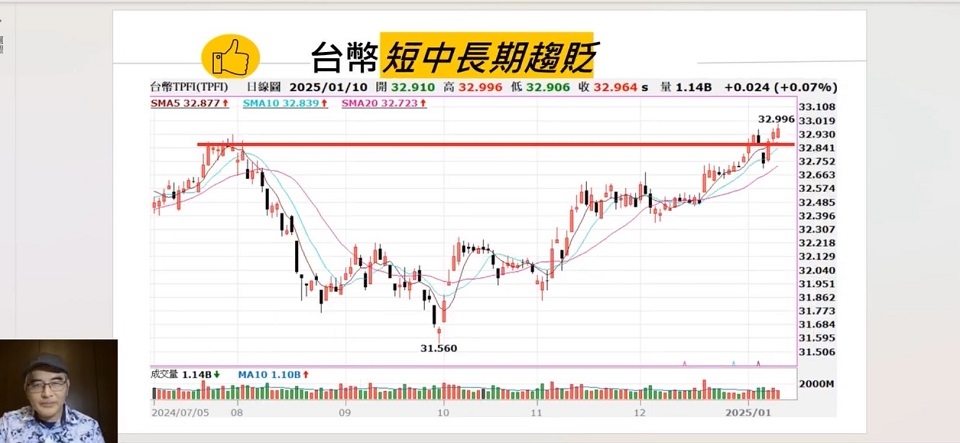  
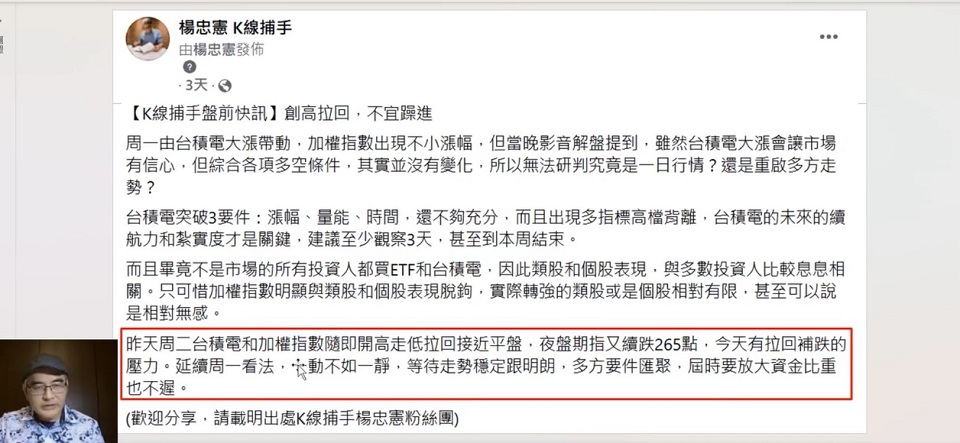  
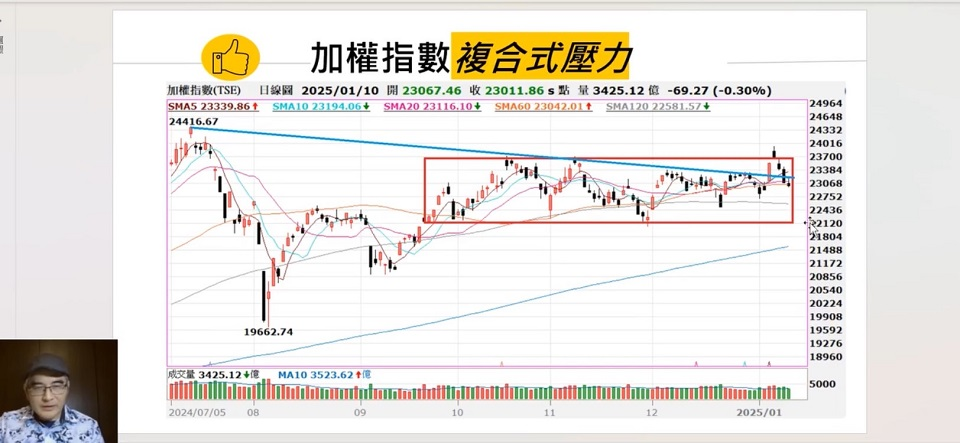  
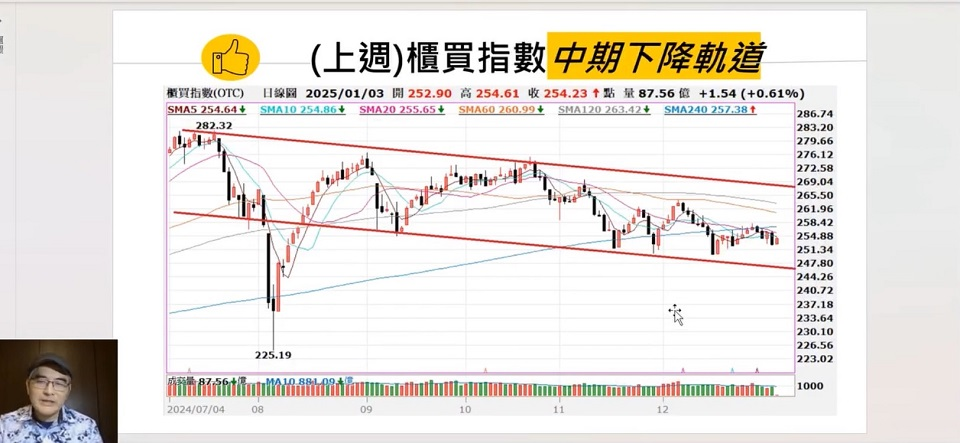  
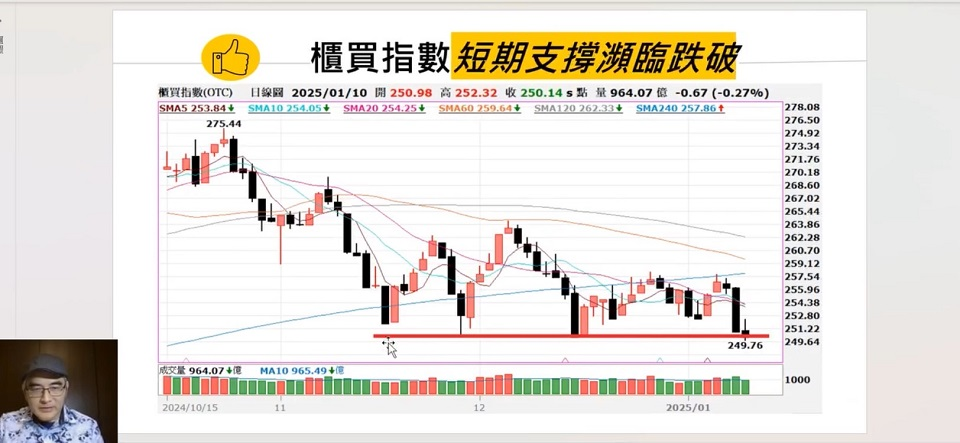  
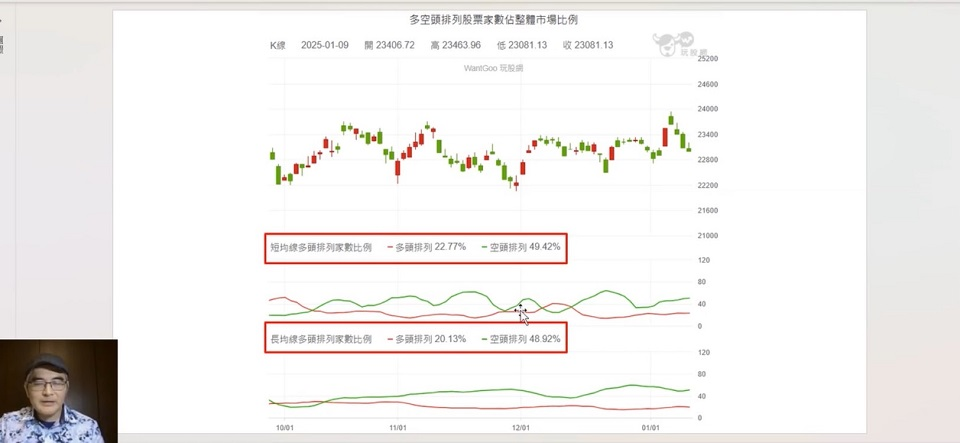  
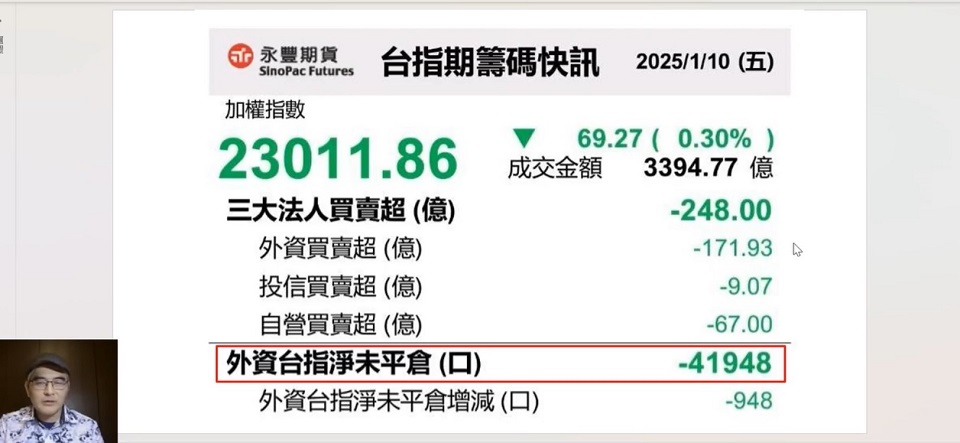  
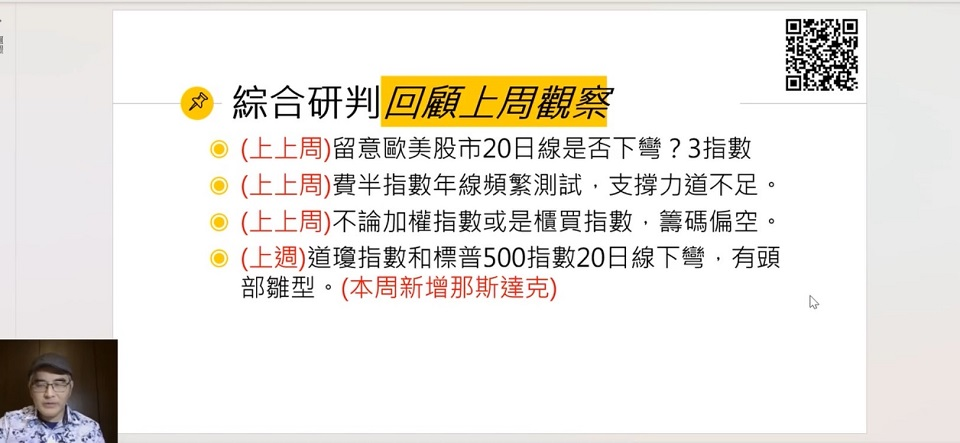  
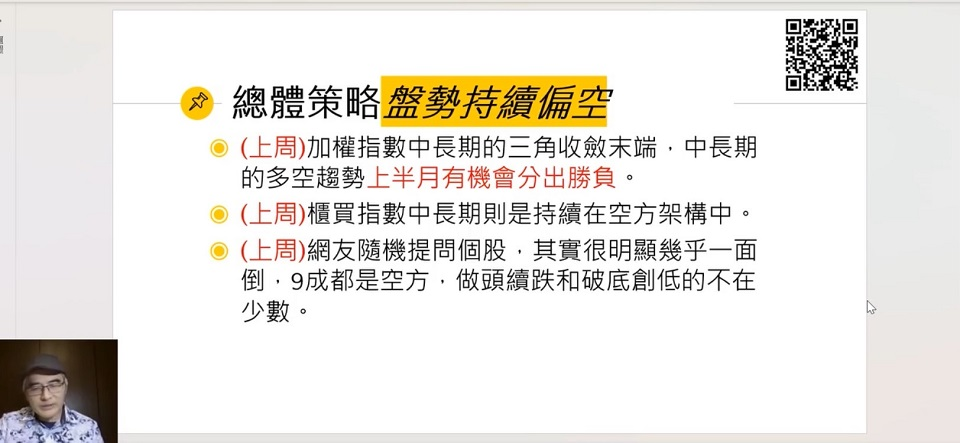  
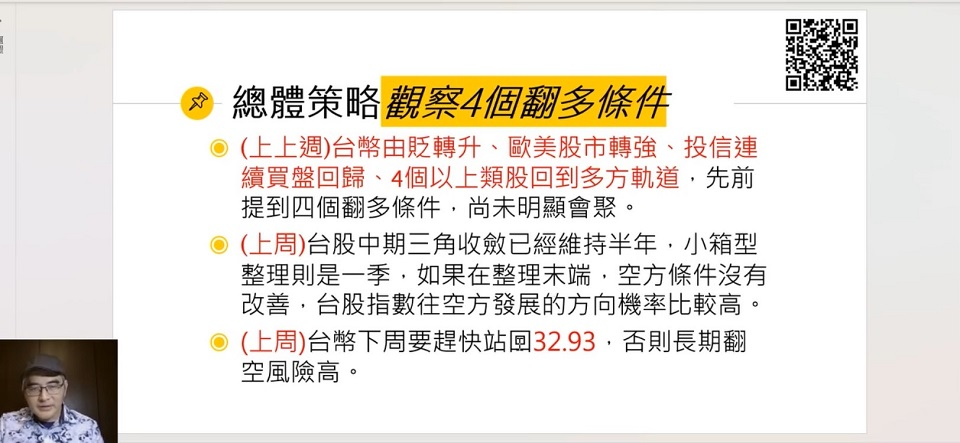  

### 本日進度  
* [1月10日](https://github.com/yilintung/StockInvestmentNotebook/blob/main/250110%E7%AD%86%E8%A8%98.ipynb)已經完成去年度投資課程，後續將會離開課程LINE群組。因此接下來從[股票老師](https://www.facebook.com/kevinyang20180801)那邊過來的資訊將會減少。  
* 股票老師於今年提供新的[服務](https://smarttest.businessweekly.com.tw/e-subscription/channel?c=GROUP00014146)，之後再確認是否訂閱。  
  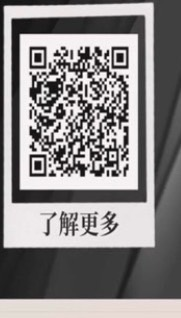  
  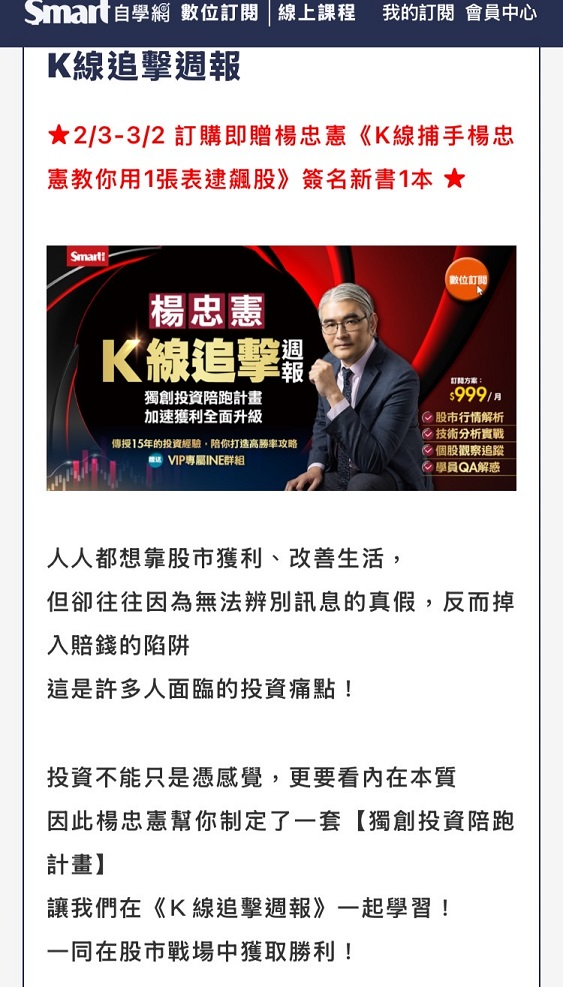  
  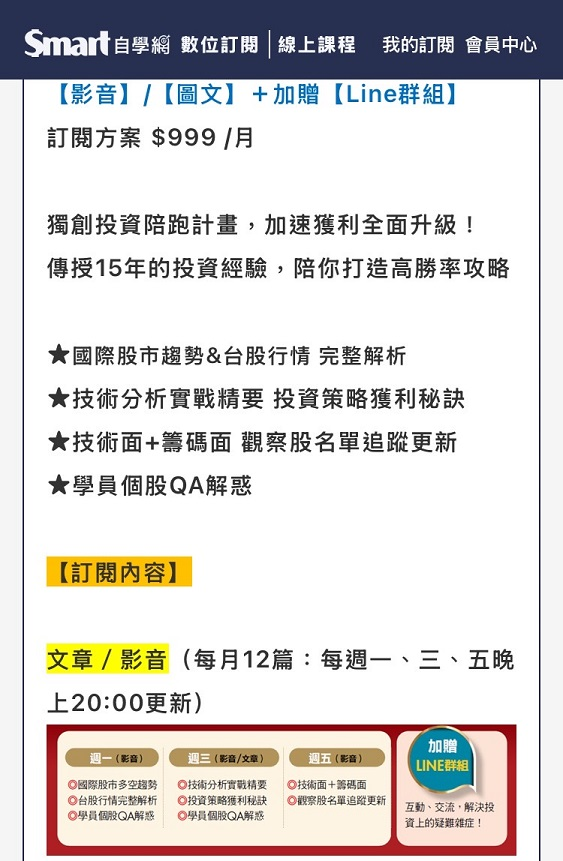  
* **程式開發**：開發底部型態偵測程序  
  - 發現[myutils](https://github.com/yilintung/StockInvestmentNotebook/tree/main/myutils)之顯著錯誤，進行相對應之修正  
  - 重構[1月10日](https://github.com/yilintung/StockInvestmentNotebook/blob/main/250110%E7%AD%86%E8%A8%98.ipynb)的bottom_pattern_detection_prototype函式，以解決偵測已突破之底部型態時之問題  

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

##### 偵測轉折點函式 #####
# prices    : 價格 (DataFrame)
# mode      : 模式 (str) ： 有'close'、'high_low'與'open_close'三種，預設為'close'
# period    : 時間窗週期 (int)
# smoothing : 平滑化參數 （當模式為'close'時有效） (int)
def DetectTurningPoints(prices, mode = 'open_close', period = 1, smoothing = 1) :
    # 價格資料確認與處理
    if prices is None or type(prices) is not pd.core.frame.DataFrame :
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None    
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 模式確認與處理
    prices_date  = np.array(in_prices['Date'])
    prices_close = np.array(in_prices['Close'])
    if mode == 'close' :
        if smoothing > 1 :
            # 若為平滑化的收盤價,使用向前與向後傳播非空值的方法填充空(NaN)值;並將窗口標籤設置為窗口索引的中心，以正確反映趨勢
            prices_smooth_close = np.array(in_prices['Close'].rolling(window=smoothing,center=True).mean().fillna(method='bfill').fillna(method='ffill'))
            prices_high = prices_smooth_close
            prices_low  = prices_smooth_close
            # 將模式改為'smooth_close'
            mode = 'smooth_close'
        else:
            prices_high = prices_close
            prices_low  = prices_close
    elif mode == 'high_low' :
        prices_high = np.array(in_prices['High'])
        prices_low  = np.array(in_prices['Low'])
    elif mode == 'open_close' :
        open_prices  = np.array(in_prices['Open'])
        close_prices = prices_close
        if len(open_prices) != len(close_prices) :
            return None
        prices_high_list = []
        prices_low_list  = []
        for idx in range(0,len(open_prices)) :
            if open_prices[idx] >= close_prices[idx] :
                prices_high_list.append(open_prices[idx])
                prices_low_list.append(close_prices[idx])
            else :
                prices_high_list.append(close_prices[idx])
                prices_low_list.append(open_prices[idx])
        prices_high = np.array(prices_high_list)
        prices_low  = np.array(prices_low_list)
    else :
        return None
    if len(prices_high) != len(prices_low) or len(prices_high) != len(prices_close) or len(prices_high) != len(prices_date) :
        return None
    total_price = len(prices_high)
    # 時間窗週期轉換為峰谷【「峰到峰」或「谷到谷」】最小寬度（ｍｉｎ＿ｗｉｄｔｈ）
    min_width = period if (period % 2) else (period + 1)
    # 峰谷最小寬度（ｍｉｎ＿ｗｉｄｔｈ）轉換為最小化過濾器的距離參數（ｏｒｄｅｒ）
    order = (min_width - 1) // 2
    order = 1 if order < 1 else order
    ### DEBUG ###
    print('ＤＥＢＵＧ ： 峰谷最小寬度 ＝ {} ， 最小化過濾器的距離參數 ＝ {} '.format(min_width,order))
    # 找出轉折點，並保存其索引
    local_min_idx = argrelextrema(prices_low,np.less,order=order)[0]
    local_max_idx = argrelextrema(prices_high,np.greater,order=order)[0]
    local_min_idx = np.array(local_min_idx)
    local_max_idx = np.array(local_max_idx)
    # 合併局部最大(波峰)與局部最小(波谷)轉折點
    local_max_min_point = []
    point_type = ''
    for idx in range(total_price):
        if idx in local_max_idx :
            if point_type != 'HI' :
                # 波谷轉波峰
                point_type = 'HI'
                if mode == 'smooth_close' :
                    local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                else :
                    local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
            else :
                # 同為波峰，選最高者
                previous_price = local_max_min_point[-1][2]
                current_price  = prices_high[idx]
                if current_price > previous_price :
                    # 移除前一筆
                    previous_point = local_max_min_point.pop()
                    # 新增目前這一筆
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                else :
                    pass
        elif idx in local_min_idx :
            if point_type != 'LO' :
                # 波峰轉波谷
                point_type = 'LO'
                if mode == 'smooth_close' :
                    local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                else :
                    local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
            else :
                # 同為波谷，選最低者
                previous_price = local_max_min_point[-1][2]
                current_price  = prices_low[idx]
                if current_price < previous_price :
                    # 移除前一筆
                    previous_point = local_max_min_point.pop()
                    # 新增目前這一筆
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                else :
                    pass
    local_max_min_point = pd.DataFrame(local_max_min_point,columns=['DateIndex','Date','Price','Type'])
    # 轉換為輸出格式
    max_min = local_max_min_point.set_index('DateIndex')
    return local_min_idx,local_max_idx,max_min

In [2]:
import pandas as pd
import numpy as np

def check_trend_line(support: bool, pivot: int, slope: float, y: np.array):
    # compute sum of differences between line and prices, 
    # return negative val if invalid 
    
    # Find the intercept of the line going through pivot point with given slope
    intercept = -slope * pivot + y[pivot]
    line_vals = slope * np.arange(len(y)) + intercept
     
    diffs = line_vals - y
    
    # Check to see if the line is valid, return -1 if it is not valid.
    if support and diffs.max() > 1e-5:
        return -1.0
    elif not support and diffs.min() < -1e-5:
        return -1.0

    # Squared sum of diffs between data and line 
    err = (diffs ** 2.0).sum()
    return err;

def optimize_slope(support: bool, pivot:int , init_slope: float, y: np.array):
    # Amount to change slope by. Multiplyed by opt_step
    slope_unit = (y.max() - y.min()) / len(y) 
    
    # Optmization variables
    opt_step = 1.0
    min_step = 0.0001
    curr_step = opt_step # current step
    
    # Initiate at the slope of the line of best fit
    best_slope = init_slope
    best_err = check_trend_line(support, pivot, init_slope, y)
    assert(best_err >= 0.0) # Shouldn't ever fail with initial slope

    get_derivative = True
    derivative = None
    while curr_step > min_step:

        if get_derivative:
            # Numerical differentiation, increase slope by very small amount
            # to see if error increases/decreases. 
            # Gives us the direction to change slope.
            slope_change = best_slope + slope_unit * min_step
            test_err = check_trend_line(support, pivot, slope_change, y)
            derivative = test_err - best_err;
            
            # If increasing by a small amount fails, 
            # try decreasing by a small amount
            if test_err < 0.0:
                slope_change = best_slope - slope_unit * min_step
                test_err = check_trend_line(support, pivot, slope_change, y)
                derivative = best_err - test_err

            if test_err < 0.0: # Derivative failed, give up
                raise Exception("Derivative failed. Check your data. ")

            get_derivative = False

        if derivative > 0.0: # Increasing slope increased error
            test_slope = best_slope - slope_unit * curr_step
        else: # Increasing slope decreased error
            test_slope = best_slope + slope_unit * curr_step
        

        test_err = check_trend_line(support, pivot, test_slope, y)
        if test_err < 0 or test_err >= best_err: 
            # slope failed/didn't reduce error
            curr_step *= 0.5 # Reduce step size
        else: # test slope reduced error
            best_err = test_err 
            best_slope = test_slope
            get_derivative = True # Recompute derivative
    
    # Optimize done, return best slope and intercept
    return (best_slope, -best_slope * pivot + y[pivot])

def fit_trendlines_single(data: np.array):
    # find line of best fit (least squared) 
    # coefs[0] = slope,  coefs[1] = intercept 
    x = np.arange(len(data))
    coefs = np.polyfit(x, data, 1)

    # Get points of line.
    line_points = coefs[0] * x + coefs[1]

    # Find upper and lower pivot points
    upper_pivot = (data - line_points).argmax() 
    lower_pivot = (data - line_points).argmin() 
   
    # Optimize the slope for both trend lines
    support_coefs = optimize_slope(True, lower_pivot, coefs[0], data)
    resist_coefs = optimize_slope(False, upper_pivot, coefs[0], data)

    return (support_coefs, resist_coefs) 

def fit_trendlines_high_low(high: np.array, low: np.array, close: np.array):
    x = np.arange(len(close))
    coefs = np.polyfit(x, close, 1)
    # coefs[0] = slope,  coefs[1] = intercept
    line_points = coefs[0] * x + coefs[1]
    upper_pivot = (high - line_points).argmax() 
    lower_pivot = (low - line_points).argmin() 
    
    support_coefs = optimize_slope(True, lower_pivot, coefs[0], low)
    resist_coefs = optimize_slope(False, upper_pivot, coefs[0], high)

    return (support_coefs, resist_coefs)

##### 擬合趨勢線函式 #####
# prices         : 價格 (DataFrame)
# mode           : 模式 (str)
def TrendlineAutomation(prices, mode = 'close') :
    # 價格資料確認與處理
    if prices is None or type(prices) is not pd.core.frame.DataFrame :
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None    
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 模式確認與處理
    prices_close=np.array(in_prices['Close'])
    if mode == 'close' :
        pass
    elif mode == 'high_low' :
        prices_high = np.array(in_prices['High'])
        prices_low = np.array(in_prices['Low'])
    elif mode == 'open_close' :
        open_prices  = np.array(in_prices['Open'])
        close_prices = prices_close
        prices_high_list = []
        prices_low_list  = []
        for idx in range(0,len(open_prices)) :
            if open_prices[idx] >= close_prices[idx] :
                prices_high_list.append(open_prices[idx])
                prices_low_list.append(close_prices[idx])
            else :
                prices_high_list.append(close_prices[idx])
                prices_low_list.append(open_prices[idx])
        prices_high = np.array(prices_high_list)
        prices_low  = np.array(prices_low_list)
    else :
        return None
    # 擬合趨勢線
    if mode == 'close' :
        trendlines = fit_trendlines_single(prices_close)
    elif mode == 'high_low' or mode == 'open_close' :
        trendlines = fit_trendlines_high_low(prices_high,prices_low,prices_close)
    # 輸出格式處理
    trendline_start_index = in_prices.iloc[0].name
    trendline_end_index = in_prices.iloc[-1].name
    trendline_start_date = in_prices.iloc[0]['Date'].strftime('%Y-%m-%d')
    trendline_end_date = in_prices.iloc[-1]['Date'].strftime('%Y-%m-%d')
    support_slope  = trendlines[0][0]
    support_intercept = trendlines[0][1]
    support_trendline_start_price = support_slope * trendline_start_index + support_intercept
    support_trendline_end_price = support_slope * trendline_end_index + support_intercept
    resist_slope = trendlines[1][0]
    resist_intercept = trendlines[1][1]
    resist_trendline_start_price = resist_slope * trendline_start_index + resist_intercept
    resist_trendline_end_price = resist_slope * trendline_end_index + resist_intercept
    # 回傳資料處理
    ret_trendlines =  [[(trendline_start_date,support_trendline_start_price),(trendline_end_date,support_trendline_end_price)],
                       [(trendline_start_date,resist_trendline_start_price),(trendline_end_date,resist_trendline_end_price)]]
    return (trendlines,ret_trendlines)

In [3]:
# TODO : 開發中，並且尚未處理底部型態突破
def bottom_pattern_detection_prototype(prices, turning_points) :
    ### DEBUG ###
    print('ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃')
    # 價格資料確認與處理
    if prices is None or type(prices) is not pd.core.frame.DataFrame :
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 轉折點確認與處理
    if turning_points is None or type(turning_points) is not pd.core.frame.DataFrame :
        return None
    if 'Date' not in turning_points.columns or 'Price' not in turning_points.columns or 'Type' not in turning_points.columns :
        return None
    turning_points_len = len(turning_points)
    # 回傳資料列表
    bottom_pattern_ret_list = []
    # 偵測底部型態
    turning_points_check_start = 0
    check_next_pattern         = False
    while True :
        previous_high_point        = None
        bottom_pattern_high_point  = None
        bottom_pattern_low_point   = None
        bottom_pattern_start_point = None
        bottom_pattern_end_date    = None
        turning_points_chk_range   = range(turning_points_check_start,turning_points_len)
        check_next_pattern         = False
                
        # 轉折高點確認
        prev_hi_point = None
        for idx in turning_points_chk_range:
            point = turning_points.iloc[idx]
            if point['Type'] == 'HI' :
                if prev_hi_point is not None :
                    if previous_high_point is None or bottom_pattern_high_point is None :
                        if ((prev_hi_point['Price'] - point['Price']) / prev_hi_point['Price']) > 0.15 :
                            previous_high_point       = prev_hi_point
                            bottom_pattern_high_point = point
                        else :
                            pass
                    else :
                        if point['Price'] > previous_high_point['Price'] :
                            # TODO : 這部份程序待檢討
                            turning_points_chk_range   = range(turning_points_check_start,idx)
                            turning_points_check_start = idx
                            check_next_pattern         = True
                            print('ＤＥＢＵＧ ： 非底型的轉折點 ＝ {} ，調整後轉折低點確認範圍 ＝ {} '.format(point,*turning_points_chk_range))
                            break
                        if point['Price'] > bottom_pattern_high_point['Price'] :
                            if ((previous_high_point['Price'] - point['Price']) / previous_high_point['Price']) > 0.15 :
                                bottom_pattern_high_point = point
                            else :
                                # TODO : 這部份程序待檢討
                                turning_points_chk_range   = range(turning_points_check_start,idx)
                                turning_points_check_start = idx
                                check_next_pattern         = True
                                print('ＤＥＢＵＧ ： 非底型的轉折點 ＝ {} ，調整後轉折低點確認範圍 ＝ {} '.format(point,*turning_points_chk_range))
                                break
                prev_hi_point = point
        
        # 轉折低點確認
        prev_lo_point = None
        for idx in turning_points_chk_range:
            point = turning_points.iloc[idx]
            if point['Type'] == 'LO' :
                if idx > 0 and previous_high_point is not None and turning_points.iloc[idx-1]['Date'] == previous_high_point['Date'] :
                    bottom_pattern_start_point = point
                if bottom_pattern_low_point is None :
                    bottom_pattern_low_point  = point
                if prev_lo_point is not None :
                    if point['Price'] < bottom_pattern_low_point['Price'] :
                        bottom_pattern_low_point = point
                prev_lo_point = point
            bottom_pattern_last_point = point
        
        if previous_high_point is not None and bottom_pattern_high_point is not None and bottom_pattern_start_point is not None and bottom_pattern_low_point is not None :
            # 設定底部型態開始與結束索引與日期
            bottom_pattern_start_idx  = bottom_pattern_start_point.name
            bottom_pattern_start_date = bottom_pattern_start_point['Date']
            # TODO : 以下程序待檢討
            bottom_pattern_end_idx  = bottom_pattern_last_point.name
            bottom_pattern_end_date = bottom_pattern_last_point['Date']
            for idx in range(bottom_pattern_end_idx, in_prices.shape[0]) :
                if in_prices.iloc[idx]['Close'] > bottom_pattern_high_point['Price'] or in_prices.iloc[idx]['Open'] > bottom_pattern_high_point['Price'] :
                    bottom_pattern_end_idx  = idx - 1
                    bottom_pattern_end_date = in_prices.iloc[bottom_pattern_end_idx]['Date']
                    break
            ### DEBUG ###
            print('ＤＥＢＵＧ ： 底部型態開始索引 ＝ {} （日期 ＝ {} ） ， 底部型態結束索引 ＝ {} （日期 ＝ {} ）'.format(bottom_pattern_start_idx,bottom_pattern_start_date,bottom_pattern_end_idx,bottom_pattern_end_date))
            # 使用趨勢線做為頸線
            range_prices = in_prices[bottom_pattern_start_idx:(bottom_pattern_end_idx+1)]
            ### DEBUG ###
            print();print('ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝ {}'.format(range_prices));print()
            parms,_ = TrendlineAutomation(range_prices,'open_close')
            # 取得頸線相關參數
            neckline_slope     = parms[1][0]
            neckline_intercept = parms[1][1]
            # 設定頸線開始位置與價格
            # TODO : 這部份程序待檢討
            previous_high_idx    = previous_high_point.name
            neckline_start_idx   = previous_high_idx + ((bottom_pattern_start_idx - previous_high_idx) // 2)
            neckline_start_date  = in_prices.iloc[neckline_start_idx]['Date'].strftime("%Y-%m-%d")
            neckline_start_price = (neckline_slope * (neckline_start_idx - bottom_pattern_start_idx)) + neckline_intercept
            # 設定頸線結束位置與價格
            neckline_end_idx   = in_prices.iloc[-1].name
            neckline_end_date  = in_prices.iloc[neckline_end_idx]['Date'].strftime("%Y-%m-%d")
            neckline_end_price = (neckline_slope * (neckline_end_idx - bottom_pattern_start_idx)) + neckline_intercept
            # 估算目標價
            bottom_price_idx  = bottom_pattern_low_point.name
            bottom_price_date = bottom_pattern_low_point['Date'].strftime("%Y-%m-%d")
            bottom_price      = bottom_pattern_low_point['Price']
            on_neckline_price = neckline_slope * (bottom_price_idx - bottom_pattern_start_idx) + neckline_intercept
            target_price = (on_neckline_price - bottom_price) + on_neckline_price
            ### DEBUG ###
            print('ＤＥＢＵＧ ： 底部最低價格 ＝ {:.2f}元 ； 估算目標價 ＝ {:.2f}元'.format(bottom_price,target_price))
            ### DEBUG ###
            # 目標價不能過前高
            if target_price < previous_high_point['Price'] :
                print("ＤＥＢＵＧ ： 目標價沒有過前高")
            else :
                print("ＤＥＢＵＧ ： 目標價過前高")
            bottom_pattern_ret_list.append({'neckline_start_date':neckline_start_date,'neckline_start_price':neckline_start_price,
                'neckline_end_date':neckline_end_date,'neckline_end_price':neckline_end_price,
                'bottom_price_date':bottom_price_date,'bottom_price':bottom_price,
                'on_neckline_price':on_neckline_price,'target_price':target_price})
        if check_next_pattern is False :
            break
    ### DEBUG ###              
    print('ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃');print()        
    return bottom_pattern_ret_list

In [4]:
# 單元測試函式：偵測轉折點
def test_DetectTurningPoints(prices, sma, mode, period = 1, smoothing = 1) :
    _,_,max_min = DetectTurningPoints(prices,mode,period,smoothing)
    print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
    display(max_min)

    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

    # 設定均線與轉折點    
    turning_points_len = len(np.array(prices['Close']))
    turning_points = np.array([np.nan]*turning_points_len)
    for point in max_min.iterrows() :
        turning_points[point[0]] = point[1]['Price']    
    apds = [
        mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
        mpf.make_addplot(sma['SMA5'],width=1.0,color='xkcd:maroon'),
        mpf.make_addplot(sma['SMA10'],width=1.0,color='xkcd:cyan'),
        mpf.make_addplot(sma['SMA20'],width=1.5,color='xkcd:violet'),
        mpf.make_addplot(sma['SMA60'],width=0.5,color='xkcd:dark orange')
    ]

    # 繪出K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
    mpf.plot(prices,**kwargs)
    return max_min

In [5]:
# 單元測試函式：偵測底部型態
def test_bottom_pattern_detection_prototype(price,sma,mode='open_close',period=20) :

    # 偵測轉折點
    turning_points = test_DetectTurningPoints(price,sma,mode,period)

    # 偵測底型
    ret = bottom_pattern_detection_prototype(price,turning_points)
    if len(ret) < 1 :
        print('空串列！')
        return
    pattern = ret[-1]
    print(pattern);
    neckline_start_date  = pattern['neckline_start_date']
    neckline_start_price = pattern['neckline_start_price']
    neckline_end_date    = pattern['neckline_end_date']
    neckline_end_price   = pattern['neckline_end_price']
    bottom_price_date    = pattern['bottom_price_date']
    bottom_price         = pattern['bottom_price']
    on_neckline_price    = pattern['on_neckline_price']
    target_price         = pattern['target_price']
    
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

    # 設定頸線
    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
        [(bottom_price_date,bottom_price),(bottom_price_date,on_neckline_price)],
        [(neckline_end_date,neckline_end_price),(neckline_end_date,target_price)]
                         ]

    # 設定均線
    added_plots={
        "SMA5": mpf.make_addplot(sma['SMA5'],width=0.5,color='xkcd:maroon'),
        "SMA20": mpf.make_addplot(sma['SMA20'],width=1.0,color='xkcd:violet'),
        "SMA60": mpf.make_addplot(sma['SMA60'],width=0.5,color='xkcd:dark orange')
    }

    # 繪製K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True,addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(1.2,10,10), colors='xkcd:orange yellow', alpha=0.6), warn_too_much_data=1000)
    mpf.plot(price,**kwargs)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [7]:
##### 使用2024年1月2日到2025年1月9日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_3543_250109.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
23,2024-02-02,29.30,HI
45,2024-03-15,23.20,LO
61,2024-04-10,24.05,HI
69,2024-04-22,22.50,LO
80,2024-05-08,24.50,HI
84,2024-05-14,23.25,LO
95,2024-05-29,24.00,HI
142,2024-08-07,19.85,LO
175,2024-09-24,24.50,HI


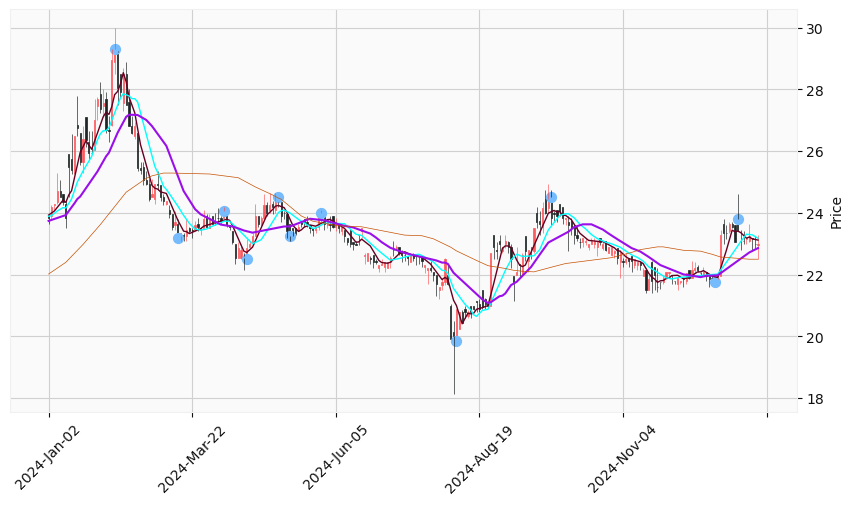

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 45 （日期 ＝ 2024-03-15 00:00:00 ） ， 底部型態結束索引 ＝ 240 （日期 ＝ 2024-12-30 00:00:00 ）

ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝           Date   Open   High    Low  Close  Volume
45  2024-03-15  23.65  23.80  23.20  23.20     261
46  2024-03-18  23.25  23.35  23.10  23.35     109
47  2024-03-19  23.30  23.35  23.10  23.25     152
48  2024-03-20  23.25  23.80  23.10  23.45     238
49  2024-03-21  23.50  23.55  23.35  23.40     170
..         ...    ...    ...    ...    ...     ...
236 2024-12-24  23.35  23.60  23.15  23.35     269
237 2024-12-25  23.40  23.70  23.35  23.65     568
238 2024-12-26  23.65  23.70  23.50  23.55     282
239 2024-12-27  23.60  23.60  23.05  23.05     204
240 2024-12-30  23.80  24.60  23.40  23.45     660

[196 rows x 6 columns]

ＤＥＢＵＧ ： 底部最低價格 ＝ 19.85元 ； 估算目標價 ＝ 29.15元
ＤＥＢＵＧ ： 目標價沒有過前高
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

{'neckline_start_date': '2024-02-29', 'neckline_start_price': 24.500101742987276, 'neckline_end_date': '2025-01-09', 'neckline_end_price': 24.49994804

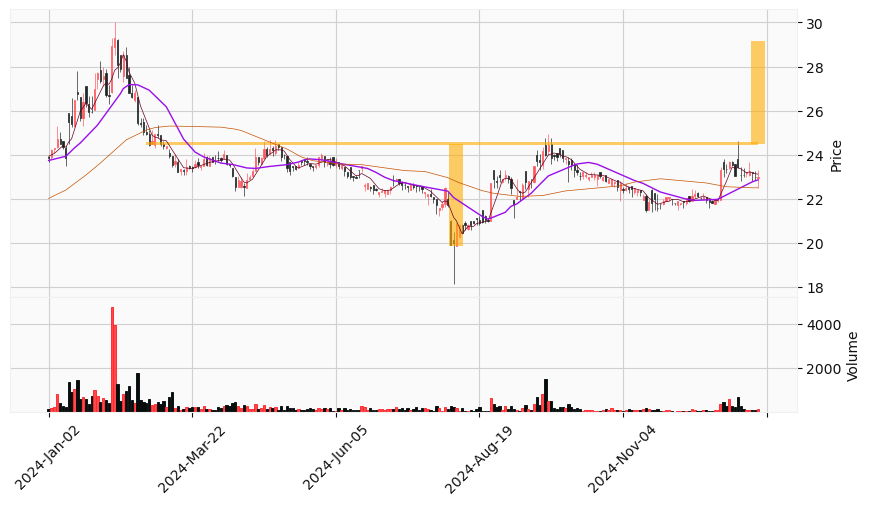

In [8]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'open_close',20)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
23,2024-02-02,29.30,HI
45,2024-03-15,23.20,LO
79,2024-05-07,24.40,HI
84,2024-05-14,23.25,LO
95,2024-05-29,24.00,HI
115,2024-06-27,22.30,LO
121,2024-07-05,22.90,HI
140,2024-08-05,19.90,LO
174,2024-09-23,24.45,HI


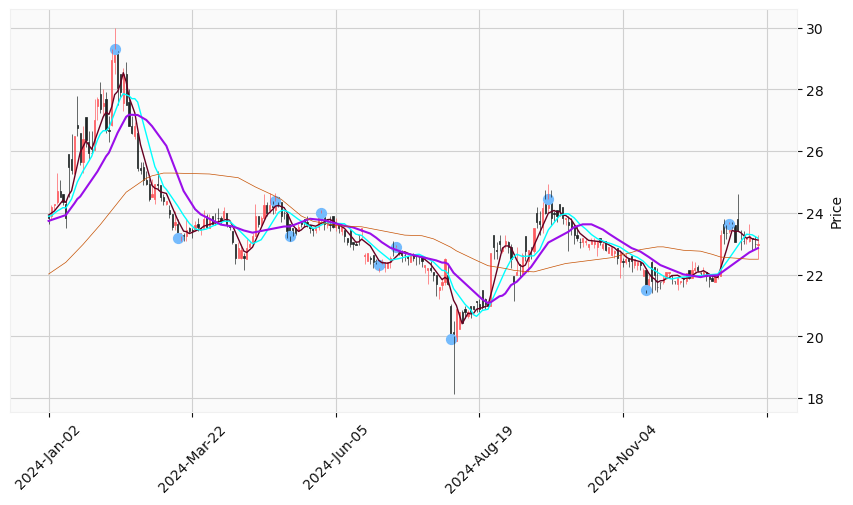

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 45 （日期 ＝ 2024-03-15 00:00:00 ） ， 底部型態結束索引 ＝ 237 （日期 ＝ 2024-12-25 00:00:00 ）

ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝           Date   Open   High    Low  Close  Volume
45  2024-03-15  23.65  23.80  23.20  23.20     261
46  2024-03-18  23.25  23.35  23.10  23.35     109
47  2024-03-19  23.30  23.35  23.10  23.25     152
48  2024-03-20  23.25  23.80  23.10  23.45     238
49  2024-03-21  23.50  23.55  23.35  23.40     170
..         ...    ...    ...    ...    ...     ...
233 2024-12-19  21.95  22.00  21.85  22.00      87
234 2024-12-20  21.95  23.45  21.95  23.30     371
235 2024-12-23  23.65  23.80  23.00  23.35     452
236 2024-12-24  23.35  23.60  23.15  23.35     269
237 2024-12-25  23.40  23.70  23.35  23.65     568

[193 rows x 6 columns]

ＤＥＢＵＧ ： 底部最低價格 ＝ 19.90元 ； 估算目標價 ＝ 29.10元
ＤＥＢＵＧ ： 目標價沒有過前高
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

{'neckline_start_date': '2024-02-29', 'neckline_start_price': 24.499990070579994, 'neckline_end_date': '2025-01-09', 'neckline_end_price': 24.50000507

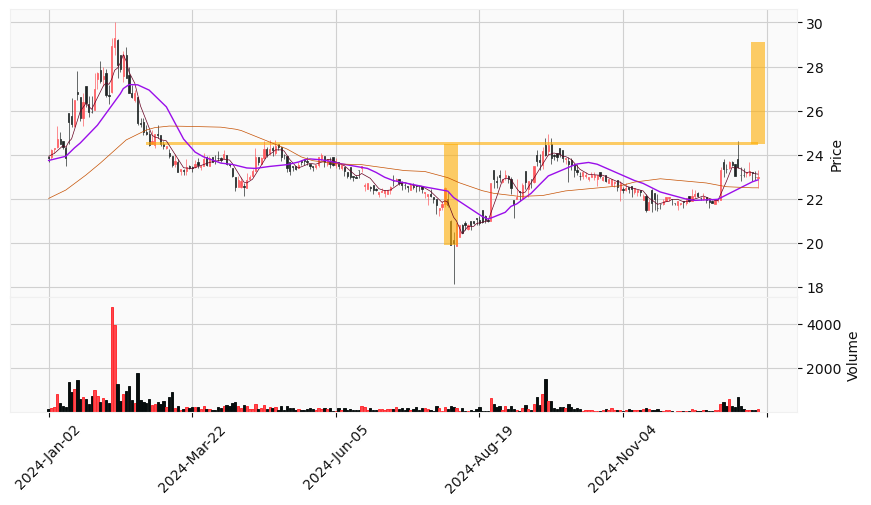

In [9]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'close',20)

In [10]:
##### 使用2023年6月5日到2024年11月7日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_2332_241107.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 12


,Date,Price,Type
DateIndex,,,
10,2023-06-19,19.95,LO
18,2023-07-03,23.15,HI
47,2023-08-14,19.25,LO
57,2023-08-28,26.15,HI
156,2024-01-18,18.50,LO
172,2024-02-20,19.95,HI
212,2024-04-19,17.20,LO
238,2024-05-28,18.85,HI
248,2024-06-12,17.65,LO


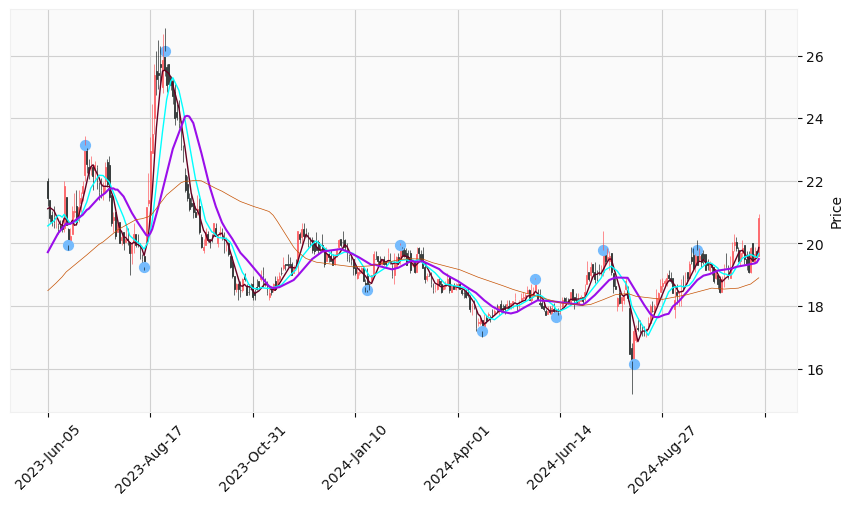

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 156 （日期 ＝ 2024-01-18 00:00:00 ） ， 底部型態結束索引 ＝ 334 （日期 ＝ 2024-10-18 00:00:00 ）

ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝           Date   Open   High    Low  Close  Volume
156 2024-01-18  18.95  19.20  18.45  18.50    2669
157 2024-01-19  18.70  18.75  18.50  18.70    1252
158 2024-01-22  18.80  19.00  18.80  19.00    1551
159 2024-01-23  19.00  19.75  19.00  19.65    8345
160 2024-01-24  19.50  19.75  19.50  19.50    2140
..         ...    ...    ...    ...    ...     ...
330 2024-10-14  18.85  19.35  18.60  19.25    2549
331 2024-10-15  19.25  19.70  19.20  19.25    3600
332 2024-10-16  18.90  19.30  18.85  18.90    2827
333 2024-10-17  18.90  19.60  18.90  19.25    2807
334 2024-10-18  19.35  20.05  19.15  19.75   10746

[179 rows x 6 columns]

ＤＥＢＵＧ ： 底部最低價格 ＝ 16.15元 ； 估算目標價 ＝ 23.51元
ＤＥＢＵＧ ： 目標價沒有過前高
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

{'neckline_start_date': '2023-11-08', 'neckline_start_price': 20.018443071870074, 'neckline_end_date': '2024-11-07', 'neckline_end_price': 19.7689417

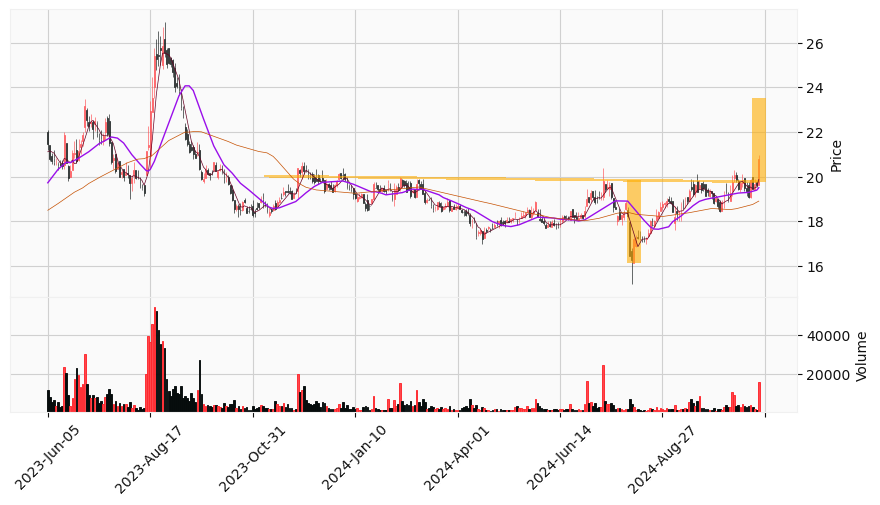

In [11]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'open_close',20)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 14


,Date,Price,Type
DateIndex,,,
10,2023-06-19,19.95,LO
18,2023-07-03,23.15,HI
47,2023-08-14,19.25,LO
56,2023-08-25,25.85,HI
100,2023-10-31,18.30,LO
124,2023-12-04,20.45,HI
156,2024-01-18,18.50,LO
172,2024-02-20,19.95,HI
212,2024-04-19,17.20,LO


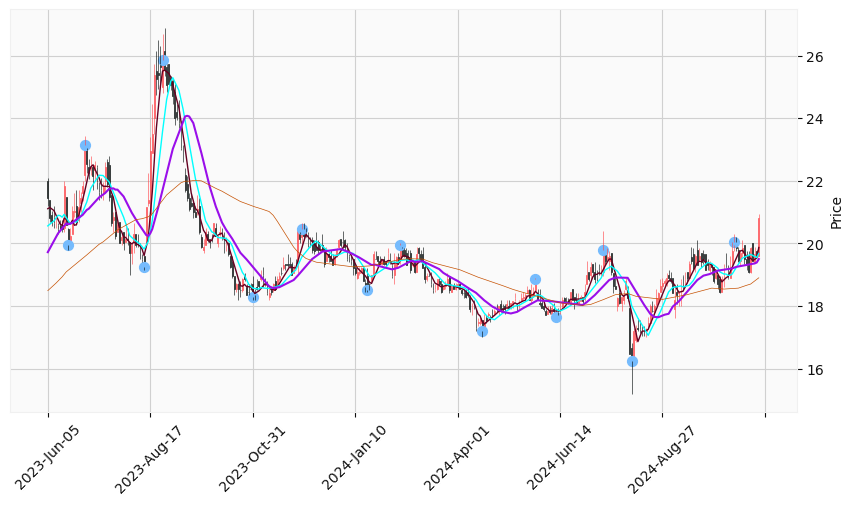

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 100 （日期 ＝ 2023-10-31 00:00:00 ） ， 底部型態結束索引 ＝ 346 （日期 ＝ 2024-11-06 00:00:00 ）

ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝           Date   Open   High    Low  Close  Volume
100 2023-10-31  18.70  18.95  18.20  18.30    3456
101 2023-11-01  18.40  18.55  18.20  18.35    1910
102 2023-11-02  18.60  18.85  18.50  18.55    2148
103 2023-11-03  18.80  18.80  18.55  18.65    2765
104 2023-11-06  18.85  19.15  18.80  19.00    3948
..         ...    ...    ...    ...    ...     ...
342 2024-10-30  19.60  19.75  19.05  19.10    3343
343 2024-11-01  19.10  19.90  19.05  19.85    3918
344 2024-11-04  20.00  20.00  19.45  19.45    2615
345 2024-11-05  19.40  19.90  19.40  19.65    1846
346 2024-11-06  19.75  19.80  19.55  19.60    1091

[247 rows x 6 columns]

ＤＥＢＵＧ ： 底部最低價格 ＝ 16.25元 ； 估算目標價 ＝ 24.04元
ＤＥＢＵＧ ： 目標價沒有過前高
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

{'neckline_start_date': '2023-09-26', 'neckline_start_price': 20.539228640395017, 'neckline_end_date': '2024-11-07', 'neckline_end_price': 20.0291414

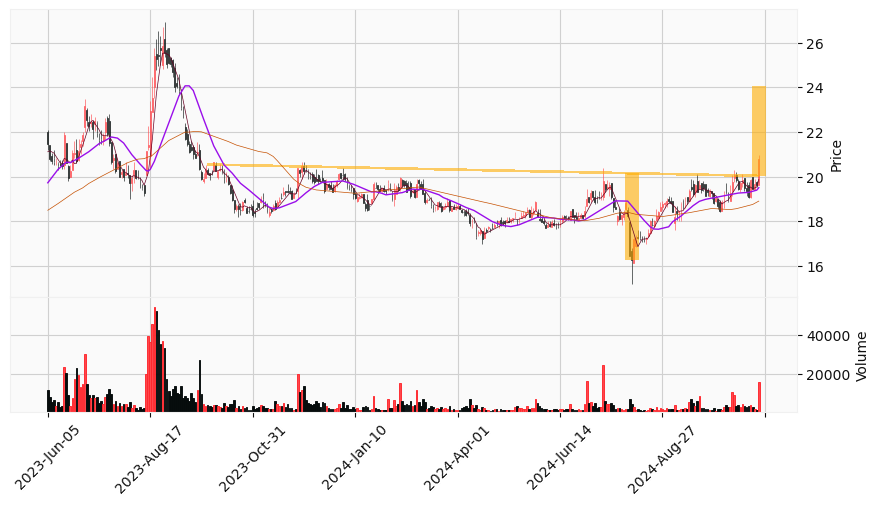

In [12]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'close',20)

In [13]:
##### 使用2022年7月6日到今日收盤(2024年10月9日)之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_3710_241009.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 15


,Date,Price,Type
DateIndex,,,
78,2022-10-26,10.20,LO
106,2022-12-05,12.70,HI
120,2022-12-23,10.90,LO
146,2023-02-10,13.20,HI
168,2023-03-16,11.60,LO
250,2023-07-18,11.35,HI
315,2023-10-23,9.20,LO
346,2023-12-05,11.00,HI
370,2024-01-09,9.90,LO


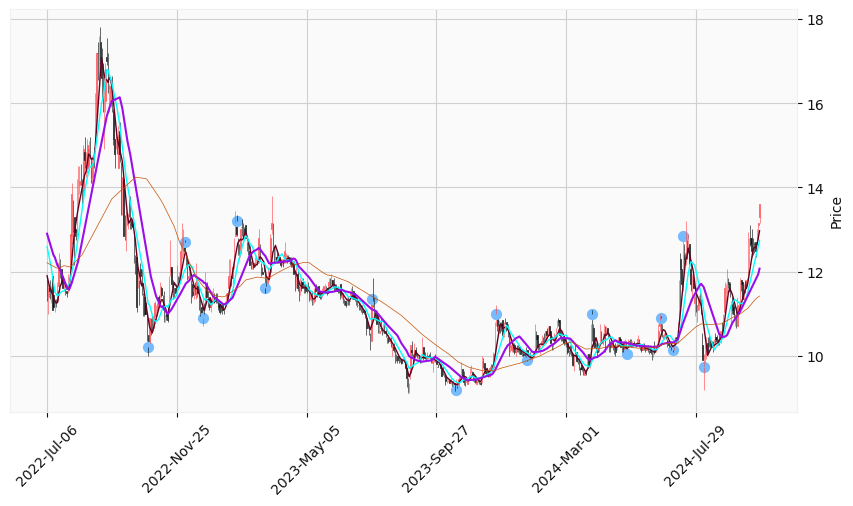

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

空串列！


In [14]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'open_close',20)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 25


,Date,Price,Type
DateIndex,,,
4,2022-07-12,11.10,LO
40,2022-08-31,17.45,HI
78,2022-10-26,10.20,LO
145,2023-02-09,13.15,HI
168,2023-03-16,11.60,LO
173,2023-03-23,13.15,HI
204,2023-05-11,11.20,LO
219,2023-06-01,11.80,HI
249,2023-07-17,10.35,LO


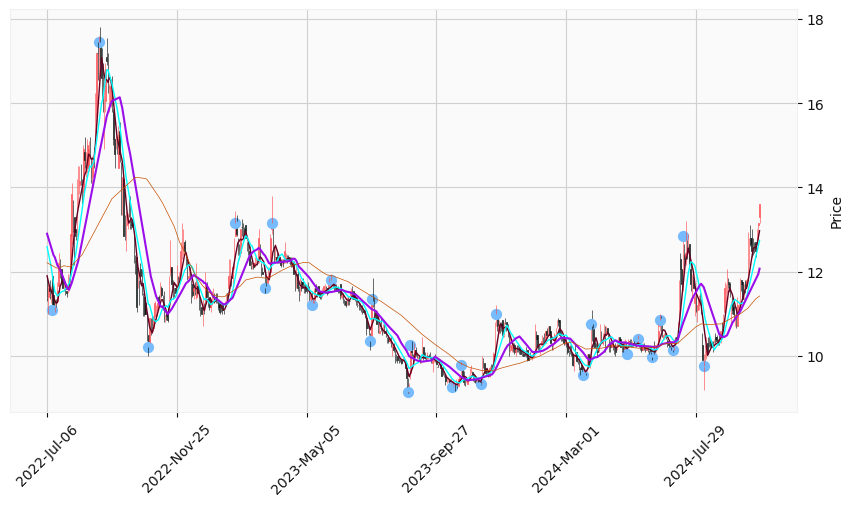

ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 78 （日期 ＝ 2022-10-26 00:00:00 ） ， 底部型態結束索引 ＝ 548 （日期 ＝ 2024-10-08 00:00:00 ）

ＤＥＢＵＧ ： 趨勢線區間價格資料 ＝           Date   Open   High    Low  Close  Volume
78  2022-10-26  10.50  10.50  10.00  10.20    3257
79  2022-10-27  10.35  10.90  10.30  10.90    2136
80  2022-10-28  10.60  10.90  10.50  10.55    1547
81  2022-10-31  10.80  10.95  10.60  10.70    1789
82  2022-11-01  10.65  10.95  10.60  10.95    1446
..         ...    ...    ...    ...    ...     ...
544 2024-09-30  12.60  12.80  12.40  12.55    1819
545 2024-10-01  12.65  12.70  12.45  12.65    1922
546 2024-10-04  12.70  12.70  12.35  12.50    2143
547 2024-10-07  12.75  13.00  12.70  12.95    5028
548 2024-10-08  13.10  13.15  12.75  13.15    4169

[471 rows x 6 columns]

ＤＥＢＵＧ ： 底部最低價格 ＝ 9.13元 ； 估算目標價 ＝ 17.24元
ＤＥＢＵＧ ： 目標價沒有過前高
ＤＥＢＵＧ ： ＃＃＃＃＃＃＃＃＃＃

{'neckline_start_date': '2022-09-28', 'neckline_start_price': 13.211071101843597, 'neckline_end_date': '2024-10-09', 'neckline_end_price': 13.149875110

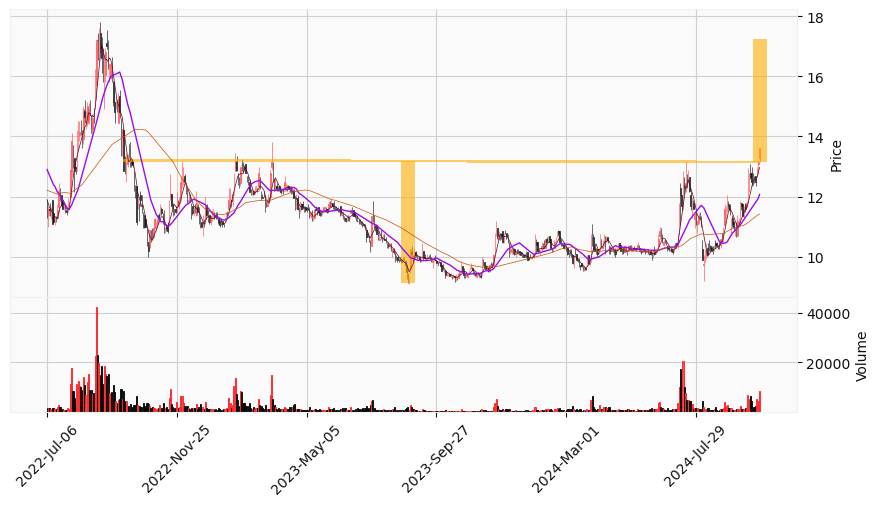

In [15]:
test_bottom_pattern_detection_prototype(df_k_line,df_sma,'close',20)